Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.1093 - val_loss: 0.0079
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0229 - val_loss: 0.0623
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0141 - val_loss: 0.0119
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0106 - val_loss: 0.0213
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0085 - val_loss: 0.0140
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0073 - val_loss: 0.0133
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0068 - val_loss: 0.0105
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0065 - val_loss: 0.0127
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0063 - val_loss: 0.0079
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0060 - val_loss: 0.0088
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0059 - val_loss: 0.0080
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0

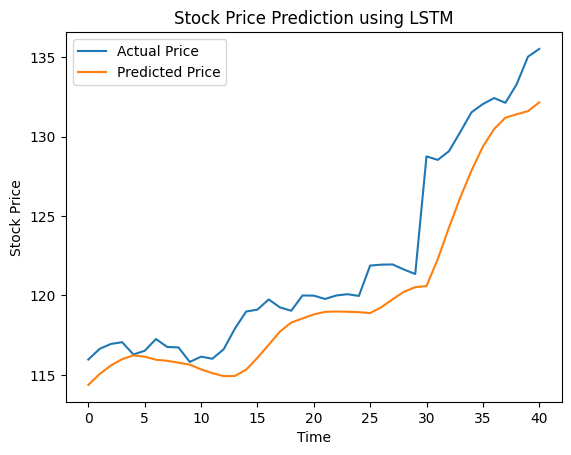

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

# Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"

df = pd.read_csv(url)

# Use Close price
data = df['AAPL.Close'].values
data = data.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# Train-test split
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

# Create dataset function
def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_dataset = create_dataset(test_data, time_step)

# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build LSTM Model
model = Sequential()

model.add(Input(shape=(time_step,1)))
model.add(LSTM(50, return_sequences=True))

model.add(LSTM(50))

model.add(Dense(1))

model.compile(loss='mean_squared_error',
              optimizer='adam')

# Train model
history = model.fit(X_train, y_train,
          validation_data=(X_test,y_dataset),
          epochs=50,
          batch_size=32)

# Prediction
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train = scaler.inverse_transform(y_train.reshape(-1,1))
y_test = scaler.inverse_transform(y_dataset.reshape(-1,1))

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, test_predict))
mae = mean_absolute_error(y_test, test_predict)

print("RMSE:", rmse)
print("MAE:", mae)

# Plot results
plt.figure()

plt.plot(y_test, label="Actual Price")
plt.plot(test_predict, label="Predicted Price")

plt.title("Stock Price Prediction using LSTM")

plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

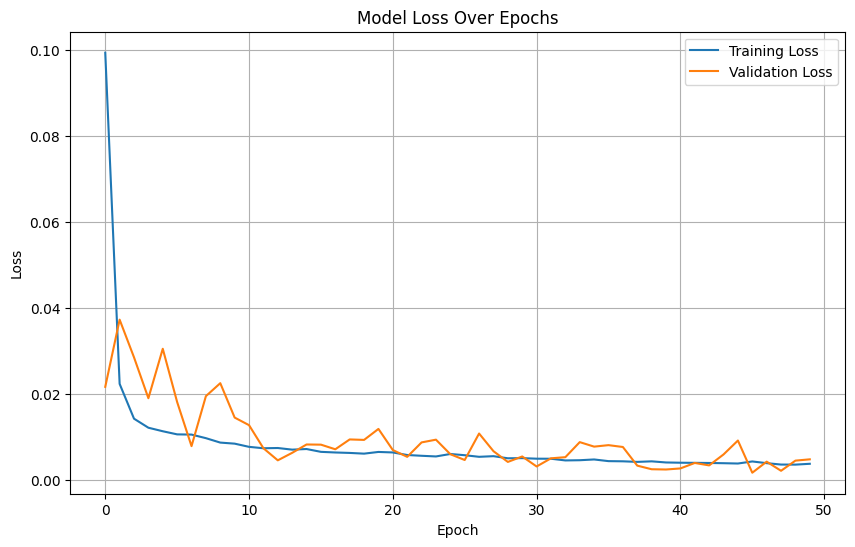

In [8]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

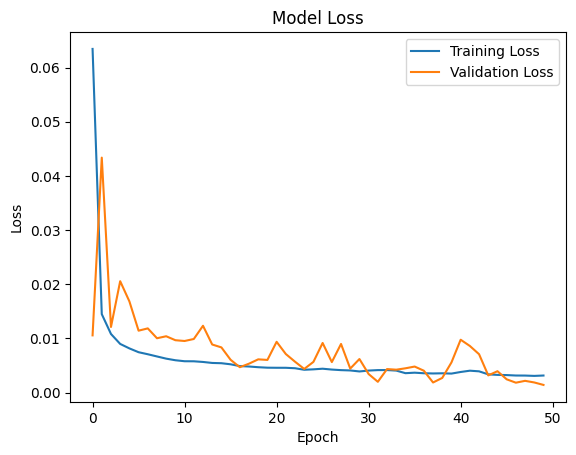

In [11]:
# Plot Training and Validation Loss

plt.figure()

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()